# 01 — Exploratory Data Analysis: Lending Club 2007–2020Q3

**Goal:** understand the data well enough to make — and defend — the decisions for Step 3 (cleaning):

1. How to define the **label**, and which loans have a trustworthy one (right-censoring)
2. Which **time window** to use (feature availability changes over the years)
3. Which columns are **leakage** (only known *after* the loan was issued)
4. What **data-quality** problems exist
5. The inputs to the **cost function** (LGD, prepayment haircut)
6. Concrete **out-of-time split** cutoffs

**Prerequisite:** `uv run python -m riskflux.data.ingest` (creates `data/interim/loans_raw.parquet`).
Every column in that parquet is a string, by design — parsing happens explicitly here and in Step 3.

> Exploration only. Nothing in `src/` imports this notebook; decisions made here get implemented as tested code in Step 3.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data/interim/loans_raw.parquet"
ALL_COLS = pq.read_schema(RAW).names

pd.set_option("display.width", 200, "display.max_rows", 200, "display.max_columns", 30)

# Chart style: validated palette slots (blue, orange, aqua), recessive axes/grid
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "lines.linewidth": 2, "legend.frameon": False,
})


def load(cols):
    return pd.read_parquet(RAW, columns=cols)


def to_num(s):
    """Parse numeric strings, including percents ('10.65%' -> 10.65). Bad values -> NaN."""
    return pd.to_numeric(s.str.rstrip("%").str.strip(), errors="coerce")


def to_month(s):
    return pd.to_datetime(s, format="%b-%Y", errors="coerce")


print(f"{len(ALL_COLS)} columns")

141 columns


## 1. Shape and integrity

In [2]:
base = load(["id", "issue_d", "term", "loan_status", "application_type"])
print(f"rows: {len(base):,}   unique ids: {base.id.nunique():,}")

junk = ~base.id.str.fullmatch(r"\d+", na=False)
base[junk]

rows: 2,925,493   unique ids: 2,925,493


,id,issue_d,term,loan_status,application_type
39786,Loans that do not meet the credit policy,NaN,NaN,NaN,NaN


**Finding:** one junk row — a leftover section header (`"Loans that do not meet the credit policy"`) from when
Lending Club published the data as several concatenated files. IDs are otherwise unique. → Step 3 drops non-numeric IDs.

In [3]:
base = base[~junk].copy()
base["issue"] = to_month(base.issue_d)
base["term"] = base.term.str.strip()
print("issue_d range:", base.issue.min().date(), "→", base.issue.max().date())

(base.loan_status.value_counts().to_frame("n")
     .assign(share=lambda d: (d.n / d.n.sum()).round(4)))

issue_d range: 2007-06-01 → 2020-09-01


,n,share
loan_status,,
Fully Paid,1497783,0.5120
Current,1031016,0.3524
Charged Off,362548,0.1239
Late (31-120 days),16154,0.0055
In Grace Period,10028,0.0034
Late (16-30 days),2719,0.0009
Issued,2062,0.0007
Does not meet the credit policy. Status:Fully Paid,1988,0.0007
Does not meet the credit policy. Status:Charged Off,761,0.0003


## 2. The label — and the right-censoring trap

`loan_status` is a **snapshot** (taken late 2020). Only *Fully Paid* and *Charged Off* (and the rare *Default*) are final
outcomes. *Current*, *Late*, *In Grace Period*, *Issued* are loans still in flight — their outcome is unknown.

Naive approach (common on Kaggle): keep every resolved loan regardless of when it was issued. Below: why that's wrong.

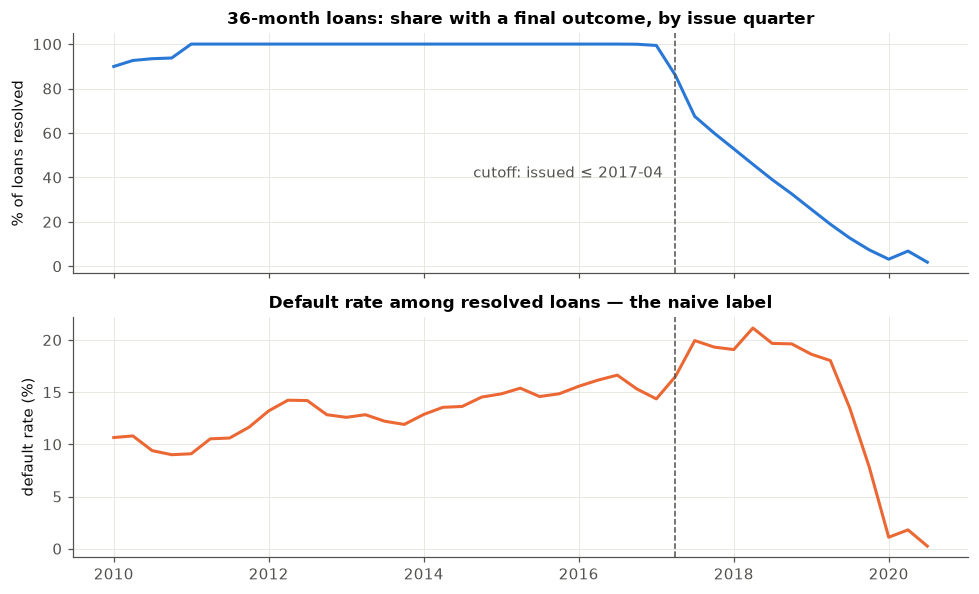

In [4]:
GOOD = {"Fully Paid"}
BAD = {"Charged Off", "Default"}

t36 = base[base.term == "36 months"].copy()
t36["resolved"] = t36.loan_status.isin(GOOD | BAD)
t36["bad"] = t36.loan_status.isin(BAD)

recent = t36[t36.issue >= "2010-01-01"]
quarter = recent.issue.dt.to_period("Q")
by_q = pd.DataFrame({
    "share_resolved": recent.groupby(quarter).resolved.mean(),
    "default_rate_among_resolved": recent[recent.resolved].groupby(quarter).bad.mean(),
})
x = by_q.index.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
ax1.plot(x, by_q.share_resolved * 100, color=BLUE)
ax1.set_ylabel("% of loans resolved")
ax1.set_title("36-month loans: share with a final outcome, by issue quarter")
ax2.plot(x, by_q.default_rate_among_resolved * 100, color=ORANGE)
ax2.set_ylabel("default rate (%)")
ax2.set_title("Default rate among resolved loans — the naive label")
for ax in (ax1, ax2):
    ax.axvline(pd.Timestamp("2017-04-01"), color=MUTED, linestyle="--", linewidth=1)
ax1.annotate("cutoff: issued ≤ 2017-04", (pd.Timestamp("2017-04-01"), 40),
             xytext=(-8, 0), textcoords="offset points", ha="right", color=MUTED)
plt.tight_layout()

**Finding — right-censoring is real and large:**
- Up to ~2017Q1 essentially 100% of 36-month loans are resolved. After that, the resolved share collapses.
- For immature cohorts, the "default rate among resolved" is **distorted**: it first *rises* (~19–21% in 2017H2–2018 —
  defaults resolve early, so they're over-represented), then *falls toward 0* (2019–2020 — too young to have defaulted).
- A model trained on those cohorts would learn a label that depends on *how old the loan is at snapshot time*, not borrower risk.

Month-level view around the cliff:

In [5]:
m = t36[(t36.issue >= "2016-10-01") & (t36.issue <= "2017-08-01")].groupby("issue")
pd.DataFrame({"n": m.size(), "share_resolved": m.resolved.mean().round(3)})

,n,share_resolved
issue,,
2016-10-01,24746,1.000
2016-11-01,26209,0.999
2016-12-01,27985,0.999
2017-01-01,24152,0.995
2017-02-01,20453,0.994
2017-03-01,27805,0.992
2017-04-01,21864,0.980
2017-05-01,27456,0.893
2017-06-01,27785,0.730


**Decision:** keep 36-month loans issued **≤ 2017-04** (≥ 98% resolved). The sharp drop at 2017-05 — sooner than a pure
36-month maturity would predict — is consistent with 2020 COVID hardship deferrals extending loans that would otherwise have
closed. The ~1–2% still unresolved in early-2017 cohorts are dropped (small, documented bias).

## 3. Feature availability changes over time

Lending Club added credit-bureau fields in waves. A column that's 100% null for older loans and populated for newer ones
lets a model learn *"when was this loan issued"* instead of *"how risky is this borrower"*.

In [6]:
issue_all = to_month(load(["issue_d"]).issue_d)
month = issue_all.dt.to_period("M")
first_avail = {}
for c in ALL_COLS:
    nonnull = load([c])[c].notna().groupby(month).mean()
    hit = nonnull[nonnull > 0.5]
    first_avail[c] = str(hit.index.min()) if len(hit) else "never >50%"

eras = pd.Series(first_avail).rename("first month >50% populated")
eras.value_counts().sort_index()

first month >50% populated
2007-06       46
2007-07       11
2007-08        1
2007-09        2
2008-03        1
2012-04        9
2012-06        2
2012-09       23
2016-01       14
never >50%    32
Name: count, dtype: int64

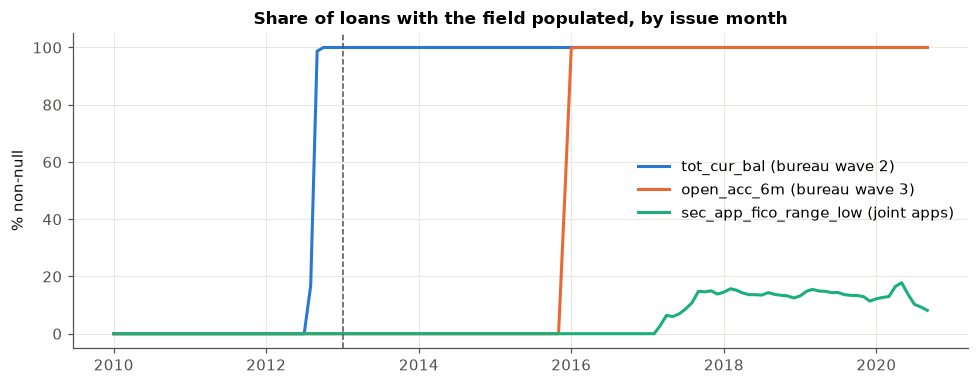

In [7]:
REPS = {"tot_cur_bal (bureau wave 2)": ("tot_cur_bal", BLUE),
        "open_acc_6m (bureau wave 3)": ("open_acc_6m", ORANGE),
        "sec_app_fico_range_low (joint apps)": ("sec_app_fico_range_low", AQUA)}
avail = load([c for c, _ in REPS.values()])
avail = avail.notna().groupby(month).mean()
avail = avail[avail.index >= pd.Period("2010-01", "M")]

fig, ax = plt.subplots(figsize=(9, 3.6))
for label, (c, color) in REPS.items():
    ax.plot(avail.index.to_timestamp(), avail[c] * 100, color=color, label=label)
ax.axvline(pd.Timestamp("2013-01-01"), color=MUTED, linestyle="--", linewidth=1)
ax.set_ylabel("% non-null")
ax.set_title("Share of loans with the field populated, by issue month")
ax.legend(loc="center right")
plt.tight_layout()

In [8]:
wave3 = sorted(c for c, v in first_avail.items() if v in {"2015-12", "2016-01"} and not c.startswith("hardship"))
print("Fields first populated late 2015 (wave 3):", wave3)

Fields first populated late 2015 (wave 3): ['all_util', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc', 'mths_since_rcnt_il', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'total_bal_il', 'total_cu_tl']


**Findings & decisions:**
- **Bureau wave 2** (~34 fields: `tot_cur_bal`, `mort_acc`, `num_*`, `mo_sin_*` …) switches on in steps from 2012-04 and is fully populated from **2012-09**.
  → Start the window at **2013-01** so every training loan has them.
- **Bureau wave 3** (14 fields: `open_acc_6m`, `il_util`, `inq_fi` …) appears in **2015-12** (majority-populated from 2016-01). Using them would mean ~3 years of
  training data with the field 100% missing. → **Exclude** from the model. *(Corner cut: a real team might train a separate
  model on post-2016 data that uses them.)*
- **Joint applications** start 2015–2017 and are rare in our window. → **Individual applications only**; drop `*_joint`, `sec_app_*`.

## 4. Population funnel

In [9]:
steps = [
    ("valid rows", pd.Series(True, index=base.index)),
    ("36-month term", base.term == "36 months"),
    ("issued 2013-01 … 2017-04", base.issue.between("2013-01-01", "2017-04-01")),
    ("individual application", base.application_type == "Individual"),
    ("resolved outcome", base.loan_status.isin(GOOD | BAD)),
]
mask = pd.Series(True, index=base.index)
rows = []
for name, cond in steps:
    mask &= cond
    rows.append((name, int(mask.sum())))
funnel = pd.DataFrame(rows, columns=["filter (cumulative)", "loans"])
funnel["kept vs previous"] = (funnel.loans / funnel.loans.shift()).round(3)
pop_idx = base.index[mask]
funnel

,filter (cumulative),loans,kept vs previous
0,valid rows,2925492,NaN
1,36-month term,2060077,0.704
2,issued 2013-01 … 2017-04,963934,0.468
3,individual application,954795,0.991
4,resolved outcome,953889,0.999


## 5. Leakage audit — every column classified

Rule: a column may be a model feature **only if it was known at the moment of the credit decision**. Everything is
classified exactly once; the assertion below fails if a column is missed or double-counted.

In [10]:
HARDSHIP = [c for c in ALL_COLS if c.startswith("hardship_") and c != "hardship_flag"] + [
    "deferral_term", "payment_plan_start_date", "orig_projected_additional_accrued_interest"]
JOINT = [c for c in ALL_COLS if c.endswith("_joint") or c.startswith("sec_app_")]

AUDIT = {
    "target": (["loan_status"], "Source of the label."),
    "split_or_filter_key": (["issue_d", "term", "application_type"],
        "Used to define population and time split; constant after filtering or not predictive by design."),
    "post_origination_LEAKAGE": ([
        "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
        "total_rec_late_fee", "recoveries", "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt",
        "next_pymnt_d", "last_credit_pull_d", "last_fico_range_high", "last_fico_range_low", "pymnt_plan",
        "hardship_flag", "debt_settlement_flag", *HARDSHIP],
        "Only known after the loan was issued (payments, recoveries, refreshed FICO, hardship, settlement). "
        "Some are used ONLY to estimate LGD / prepayment haircut on training data — never as features."),
    "lc_decision_EXCLUDED_D4": ([
        "grade", "sub_grade", "int_rate", "installment", "funded_amnt", "funded_amnt_inv",
        "initial_list_status", "verification_status"],
        "Outputs of Lending Club's own underwriting/pricing/allocation. installment reconstructs int_rate exactly "
        "(Spearman 0.9997, notebooks/01_eda.ipynb §5). Excluded from features; used in cost function and the grade ablation."),
    "fairness_proxy_EXCLUDED": (["zip_code", "addr_state", "emp_title"],
        "Geographic / occupation proxies for protected attributes. Kept only for fairness slicing."),
    "identifier_or_text_DROP": (["id", "url", "title", "policy_code"],
        "Identifiers, free text redundant with `purpose`, or constant (policy_code == 1)."),
    "late_availability_EXCLUDED": (wave3, "Bureau wave 3 — populated only from 2015-12."),
    "joint_only_EXCLUDED": (JOINT, "Joint applications are out of scope (individual only)."),
}
classified = [c for cols, _ in AUDIT.values() for c in cols]
AUDIT["candidate_feature"] = ([c for c in ALL_COLS if c not in classified],
    "Borrower / credit-bureau attributes at application time (per LC data dictionary).")

classified = [c for cols, _ in AUDIT.values() for c in cols]
assert len(classified) == len(set(classified)), "column classified twice"
assert set(classified) == set(ALL_COLS), set(ALL_COLS) ^ set(classified)

pd.DataFrame({k: len(v[0]) for k, v in AUDIT.items()}, index=["columns"]).T

,columns
target,1
split_or_filter_key,3
post_origination_LEAKAGE,32
lc_decision_EXCLUDED_D4,8
fairness_proxy_EXCLUDED,3
identifier_or_text_DROP,4
late_availability_EXCLUDED,14
joint_only_EXCLUDED,15
candidate_feature,61


In [11]:
print("Candidate features:\n", AUDIT["candidate_feature"][0])

Candidate features:
 ['loan_amnt', 'emp_length', 'home_ownership', 'annual_inc', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_pa

**Proof that `installment` leaks `int_rate`:** for a fixed 36-month term, the annuity formula makes
`installment / funded_amnt` a strictly increasing function of the interest rate. If it ranks loans identically to
`int_rate` (Spearman ≈ 1), a model given `installment` + `loan_amnt` effectively has LC's price.

In [12]:
p = load(["installment", "funded_amnt", "int_rate"]).loc[pop_idx]
ratio = to_num(p.installment) / to_num(p.funded_amnt)
spearman = ratio.rank().corr(to_num(p.int_rate).rank())  # Spearman = Pearson on ranks
print("Spearman(installment/funded_amnt, int_rate) =", round(spearman, 4))

Spearman(installment/funded_amnt, int_rate) = 0.9997


> **Assumption to state in the model card:** bureau fields (`tot_cur_bal`, `num_*`, …) are as-of application, per the LC data
> dictionary. We can't verify this from the data; if LC refreshed any of them post-issuance, they'd leak.

## 6. Data quality in the population

In [13]:
NUM_COLS = ['loan_amnt', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'revol_util', 'int_rate', 'installment', 'funded_amnt', 'total_rec_prncp', 'total_rec_int', 'recoveries', 'collection_recovery_fee']
CAT_COLS = ["home_ownership", "emp_length", "verification_status", "purpose", "grade", "earliest_cr_line"]
pop = load(NUM_COLS + CAT_COLS + ["loan_status", "issue_d"]).loc[pop_idx]
for c in NUM_COLS:
    pop[c] = to_num(pop[c])
pop["issue"] = to_month(pop.issue_d)
pop["y"] = pop.loan_status.isin(BAD).astype(int)
print(f"population: {len(pop):,} loans, default rate {pop.y.mean():.2%}")

pop[["loan_amnt", "annual_inc", "dti", "fico_range_low", "revol_util"]].describe(
    percentiles=[.01, .5, .99]).T.round(1)

population: 953,889 loans, default rate 14.71%


,count,mean,std,min,1%,50%,99%,max
loan_amnt,953889.0,12684.2,8186.3,1000.0,1500.0,10000.0,35000.0,40000.0
annual_inc,953889.0,75200.7,94760.4,3000.0,17700.0,62500.0,265000.0,61000000.0
dti,953889.0,18.1,8.4,-1.0,2.1,17.5,37.5,50.0
fico_range_low,953889.0,694.4,31.1,660.0,660.0,685.0,800.0,845.0
revol_util,953369.0,51.9,23.9,0.0,2.1,51.9,98.3,892.3


In [14]:
ecl = to_month(pop.earliest_cr_line)
issues = pd.DataFrame([
    ("annual_inc > $1M", (pop.annual_inc > 1e6).sum(), "max $61M; p99 $265k → cap/winsorize (fit on train)"),
    ("dti < 0", (pop.dti < 0).sum(), "impossible → set NaN"),
    ("revol_util > 100%", (pop.revol_util > 100).sum(), "possible (over limit), extreme up to 892% → cap"),
    ("revol_util null", pop.revol_util.isna().sum(), "impute (fit on train)"),
    ("emp_length null", pop.emp_length.isna().sum(), "missing is informative → own category"),
    ("home_ownership == ANY", (pop.home_ownership == "ANY").sum(), "rare → map to OTHER"),
    ("fico_range_high - low != 4", ((pop.fico_range_high - pop.fico_range_low) != 4).sum(), "4 wide except top band 845–850 (scale max) → use midpoint"),
    ("fico_range_low < 660", (pop.fico_range_low < 660).sum(), "LC policy floor = 660 → population is truncated"),
    ("earliest_cr_line unparseable", ecl.isna().sum(), "convert to credit-history length at issue"),
    ("purpose == educational", (pop.purpose == "educational").sum(), "rare level → fold into other"),
], columns=["check", "rows", "handling in Step 3"])
issues

,check,rows,handling in Step 3
0,annual_inc > $1M,209,max $61M; p99 $265k → cap/winsorize (fit on tr...
1,dti < 0,1,impossible → set NaN
2,revol_util > 100%,3648,"possible (over limit), extreme up to 892% → cap"
3,revol_util null,520,impute (fit on train)
4,emp_length null,63256,missing is informative → own category
5,home_ownership == ANY,385,rare → map to OTHER
6,fico_range_high - low != 4,128,4 wide except top band 845–850 (scale max) → u...
7,fico_range_low < 660,0,LC policy floor = 660 → population is truncated
8,earliest_cr_line unparseable,0,convert to credit-history length at issue
9,purpose == educational,1,rare level → fold into other


## 7. Signal sanity check — do features relate to default the way credit intuition says?

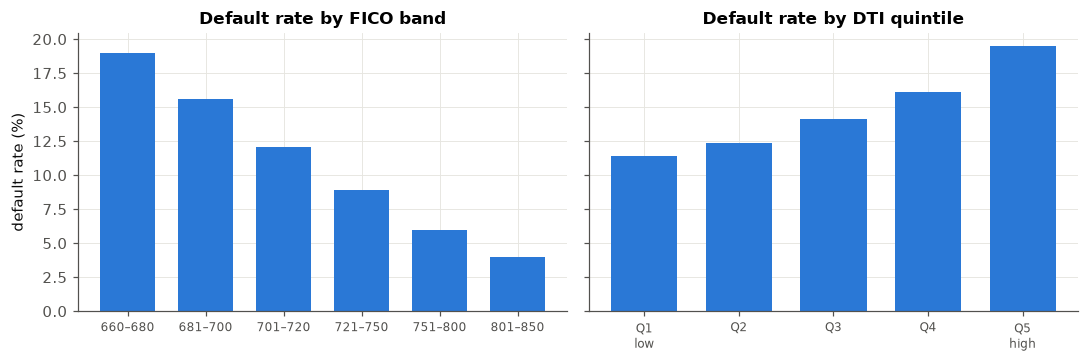

In [15]:
pop["fico"] = (pop.fico_range_low + pop.fico_range_high) / 2
fico_band = pd.cut(pop.fico, [659, 680, 700, 720, 750, 800, 850])
dti_q = pd.qcut(pop.dti, 5)

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
r = pop.groupby(fico_band, observed=True).y.mean() * 100
a.bar(range(len(r)), r.values, color=BLUE, width=0.7)
a.set_xticks(range(len(r)), [f"{int(i.left)+1}–{int(i.right)}" for i in r.index], rotation=0, fontsize=8)
a.set_title("Default rate by FICO band")
a.set_ylabel("default rate (%)")
r = pop.groupby(dti_q, observed=True).y.mean() * 100
b.bar(range(len(r)), r.values, color=BLUE, width=0.7)
b.set_xticks(range(len(r)), ["Q1\nlow", "Q2", "Q3", "Q4", "Q5\nhigh"], fontsize=8)
b.set_title("Default rate by DTI quintile")
plt.tight_layout()

In [16]:
pd.concat({c: pop.groupby(c).y.agg(n="size", default_rate="mean").round(3)
           for c in ["home_ownership", "verification_status"]})

n  default_rate
home_ownership      ANY                 385         0.132
                    MORTGAGE         441994         0.120
                    OWN              108608         0.154
                    RENT             402902         0.175
verification_status Not Verified     298134         0.113
                    Source Verified  378124         0.150
                    Verified         277631         0.180

**Findings:**
- Monotonic, strong signal: FICO 660–680 defaults at ~19% vs ~4% above 800; DTI top quintile ~2× bottom. The data is sane.
- **Counter-intuitive: "Verified" income defaults *more* (18.0%) than "Not Verified" (11.3%).** LC chooses whom to verify —
  it verifies applicants it already thinks are risky. That's **selection bias**, and a textbook reason `verification_status`
  encodes LC's judgement rather than a borrower property (→ excluded per D4).

## 8. Drift preview — the population is not stationary

issue,2013Q1,2013Q2,2013Q3,2013Q4,2014Q1,2014Q2,2014Q3,2014Q4,2015Q1,2015Q2,2015Q3,2015Q4,2016Q1,2016Q2,2016Q3,2016Q4,2017Q1,2017Q2
default_rate,0.126,0.128,0.122,0.119,0.129,0.135,0.136,0.145,0.148,0.154,0.146,0.148,0.156,0.161,0.166,0.153,0.144,0.145
mean_fico,695.970,697.077,697.074,697.194,694.005,695.291,696.027,693.077,693.765,694.834,696.488,696.729,697.838,698.006,695.773,697.002,698.857,699.448
mean_dti,17.310,16.691,16.507,16.939,17.120,16.935,17.663,18.226,18.536,18.424,18.435,18.468,18.908,18.541,17.624,18.194,17.962,17.985
n,17988.000,23136.000,27318.000,31980.000,34074.000,37881.000,40595.000,50020.000,56569.000,64222.000,73572.000,88571.000,94592.000,73666.000,73574.000,76391.000,69349.000,20391.000


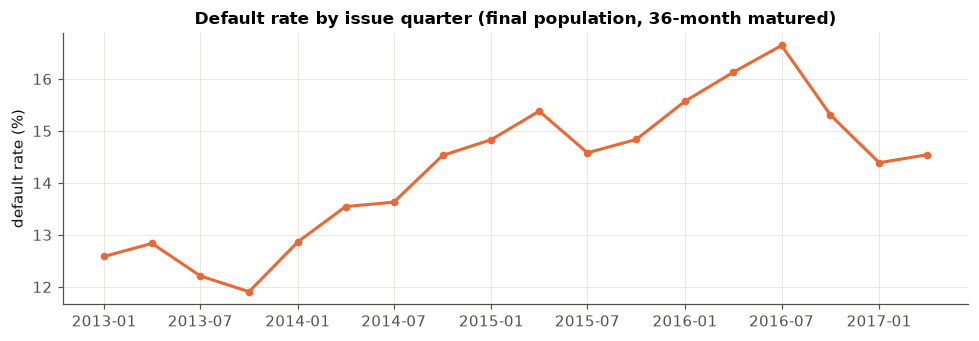

In [17]:
qd = pop.groupby(pop.issue.dt.to_period("Q")).agg(default_rate=("y", "mean"), mean_fico=("fico", "mean"),
                                                   mean_dti=("dti", "mean"), n=("y", "size"))
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(qd.index.to_timestamp(), qd.default_rate * 100, color=ORANGE, marker="o", markersize=4)
ax.set_ylabel("default rate (%)")
ax.set_title("Default rate by issue quarter (final population, 36-month matured)")
plt.tight_layout()
qd.round(3).T

**Finding:** default rate climbs from ~12% (2013) to ~16.5% (2016Q3), then eases to ~14.5% in 2017. Mean FICO and DTI move
only slightly, so these two averages explain little of it — the mix shifted in ways that need the full model to see. This is genuine **concept + covariate drift inside the training window**, and exactly why the split must be out-of-time:
a random split would hide it.

## 9. Cost-function inputs (D5)

- **LGD** — share of funded principal lost on a charged-off loan:
  `1 − (principal repaid + recoveries − collection fees) / funded_amnt`
- **Prepayment haircut** — realized interest on fully-paid loans ÷ contractual interest (`installment × 36 − funded_amnt`)

In [18]:
co = pop[pop.y == 1]
lgd = 1 - (co.total_rec_prncp + co.recoveries - co.collection_recovery_fee) / co.funded_amnt
fp = pop[pop.y == 0]
contract_int = fp.installment * 36 - fp.funded_amnt
haircut = fp.total_rec_int / contract_int

print(f"LGD:      mean {lgd.mean():.3f}   median {lgd.median():.3f}")
print(f"Haircut:  mean {haircut.mean():.3f}   median {haircut.median():.3f}")

# Break-even PD for an average loan: approve iff PD·L < (1−PD)·G  →  PD* = G / (L + G)
L = lgd.mean() * pop.funded_amnt.mean()
G = haircut.mean() * (pop.installment * 36 - pop.funded_amnt).mean()
print(f"Avg loss if default ≈ ${L:,.0f};  avg interest earned if good ≈ ${G:,.0f};  break-even PD ≈ {G / (L + G):.1%}")

LGD:      mean 0.523   median 0.542
Haircut:  mean 0.796   median 0.932
Avg loss if default ≈ $6,629;  avg interest earned if good ≈ $1,959;  break-even PD ≈ 22.8%


**Findings:** a default loses ~52% of principal; good borrowers pay only ~80% of contractual interest (early payoff).
For an average loan, rejecting becomes worthwhile above a PD of roughly the break-even printed above — far from the 0.5 a
naive classifier uses. That gap is the business case for cost-based thresholding.

*Corner cut:* LGD here ignores interest collected before default and the time value of money; no cost of funds or servicing fee.
These numbers are estimated on the **training split only** in Step 6 — shown here on the full population for exploration.

## 10. Out-of-time split proposal (D3)

In [19]:
SPLITS = {"train": ("2013-01-01", "2015-12-01"), "val": ("2016-01-01", "2016-06-01"), "test": ("2016-07-01", "2017-04-01")}
pd.DataFrame({name: {"from": a[:7], "to": b[:7], "loans": int(pop.issue.between(a, b).sum()),
                     "default_rate": round(pop.y[pop.issue.between(a, b)].mean(), 4)}
              for name, (a, b) in SPLITS.items()}).T

,from,to,loans,default_rate
train,2013-01,2015-12,545926,0.1407
val,2016-01,2016-06,168258,0.1581
test,2016-07,2017-04,239705,0.1539


**Rationale:** train on 3 years; validate (early stopping, calibration, threshold) on the next 6 months; test once on the
following 10 months. Each split is strictly later than the one before.

*Corner cut:* the split assumes labels are available immediately. In reality, a model trained in mid-2016 couldn't know the
outcomes of 2015 loans (they mature in 2018). A real team would backtest with as-of-date label availability. We simulate
label delay properly in the retraining loop (Step 10).

**Replay stream for drift monitoring (Step 9):** all loans issued 2017-05 → 2020-09 (features only; labels immature).

## 11. Decisions carried into Step 3

| Topic | Decision |
|---|---|
| Junk rows | Drop non-numeric `id` (1 row) |
| Label | `Charged Off`/`Default` → 1, `Fully Paid` → 0; drop in-flight statuses |
| Population | 36-month, individual, issued 2013-01 … 2017-04, resolved |
| Features | 61 candidates (see audit); drop leakage, LC decisions, proxies, wave-3 & joint fields |
| Data quality | Cap `annual_inc` & `revol_util`, `dti<0`→NaN, FICO midpoint, credit-history length, rare-level folding, informative-missing categories |
| Split | train 2013-01…2015-12 · val 2016-01…2016-06 · test 2016-07…2017-04 |
| Cost inputs | LGD & prepayment haircut re-estimated on train split only |

In [20]:
# Export the column audit (single source of truth until Step 4 turns it into src/riskflux/features/allowlist.py)
lines = ["# Column Audit", "",
         "Generated by `notebooks/01_eda.ipynb`. Every raw column is classified exactly once.", ""]
for cat, (cols, why) in AUDIT.items():
    lines += [f"## {cat} ({len(cols)})", "", why, "", ", ".join(f"`{c}`" for c in cols), ""]
(ROOT / "docs/COLUMN_AUDIT.md").write_text("\n".join(lines))
print("wrote docs/COLUMN_AUDIT.md")

wrote docs/COLUMN_AUDIT.md
